## **Step :1.Import Libraries** ##

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Set style for plots
sns.set_style('whitegrid')
%matplotlib inline

## **Step:1.Load The Dataset** ##

In [2]:
df = pd.read_csv('Customer_Segmentation_Data.csv')
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


## **Step:3.Explore the Data** ##

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [4]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

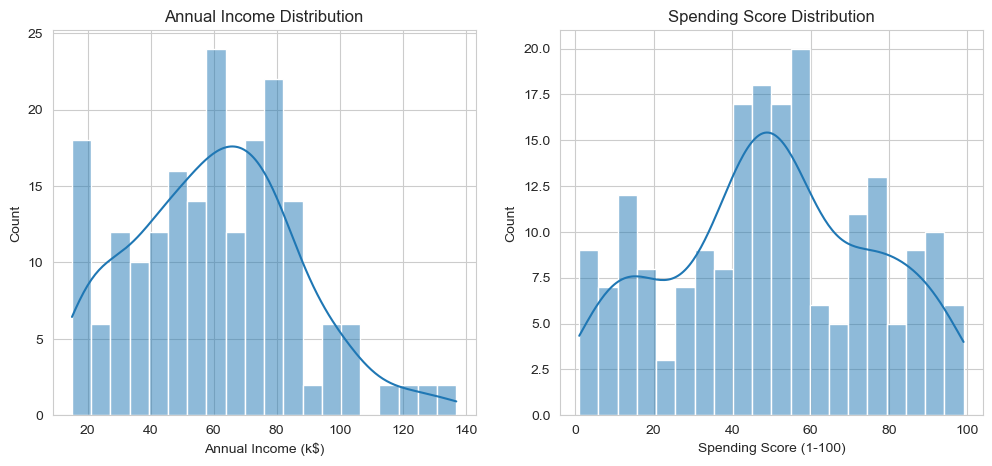

In [5]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df['Annual Income (k$)'], bins=20, kde=True)
plt.title('Annual Income Distribution')

plt.subplot(1,2,2)
sns.histplot(df['Spending Score (1-100)'], bins=20, kde=True)
plt.title('Spending Score Distribution')
plt.show()

## **Step:4. Select Features for Clustering** ##

In [6]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## **Step:5. Determine Optimal Number of Clusters** ##

### **5.1 Elbow Method** ###

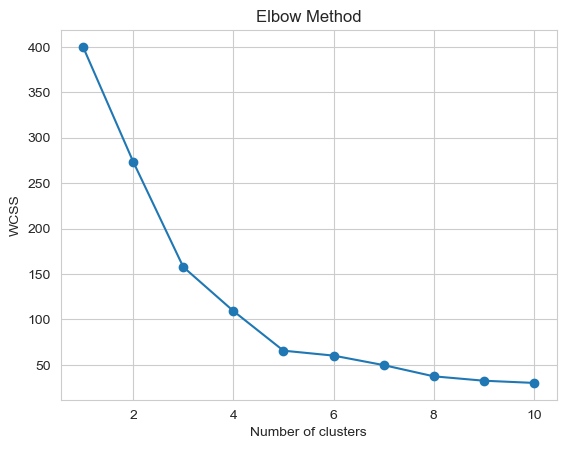

In [8]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

### **5.2 Silhouette Score** ###

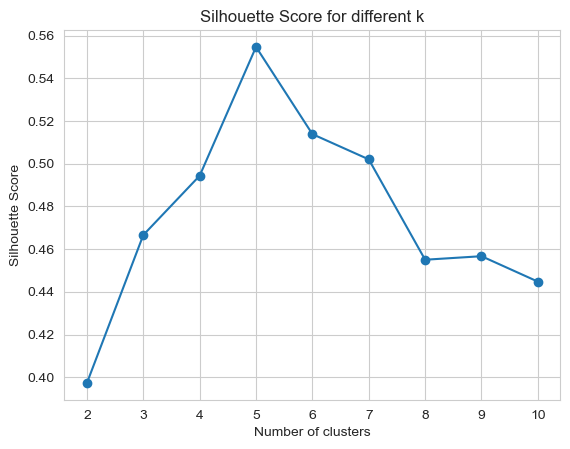

In [9]:
sil_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.plot(range(2, 11), sil_scores, marker='o')
plt.title('Silhouette Score for different k')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()

## **Step:6. Apply K-Means with Optimal k** ##

In [10]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Add the cluster labels to the original dataframe
df['Cluster'] = clusters

## **Step :7. Visualize the Clusters** ##

### **7.1 Original scale (Annual Income vs Spending Score)** ###

plt.figure(figsize=(10,6))
scatter = plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], 
                      c=df['Cluster'], cmap='viridis', s=50)
plt.colorbar(scatter)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments (K-Means with k=5)')
plt.show()

### **7.2 Using PCA for higher dimensions (if you had more features)** ###


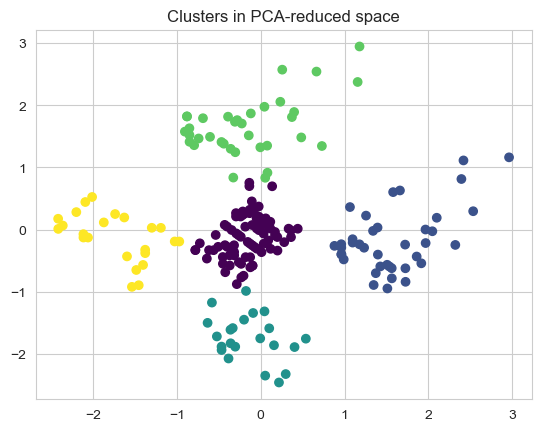

In [12]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis')
plt.title('Clusters in PCA-reduced space')
plt.show()

## **Step: 8.Analyze Each Cluster** ##

In [13]:
cluster_summary = df.groupby('Cluster').agg({
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean',
    'Age': 'mean',
    'Gender': lambda x: x.value_counts().index[0]  # majority gender
}).reset_index()

print(cluster_summary)

   Cluster  Annual Income (k$)  Spending Score (1-100)        Age  Gender
0        0           55.296296               49.518519  42.716049  Female
1        1           86.538462               82.128205  32.692308  Female
2        2           25.727273               79.363636  25.272727  Female
3        3           88.200000               17.114286  41.114286    Male
4        4           26.304348               20.913043  45.217391  Female


## **Step:9. Visualize Cluster Characteristics** ##

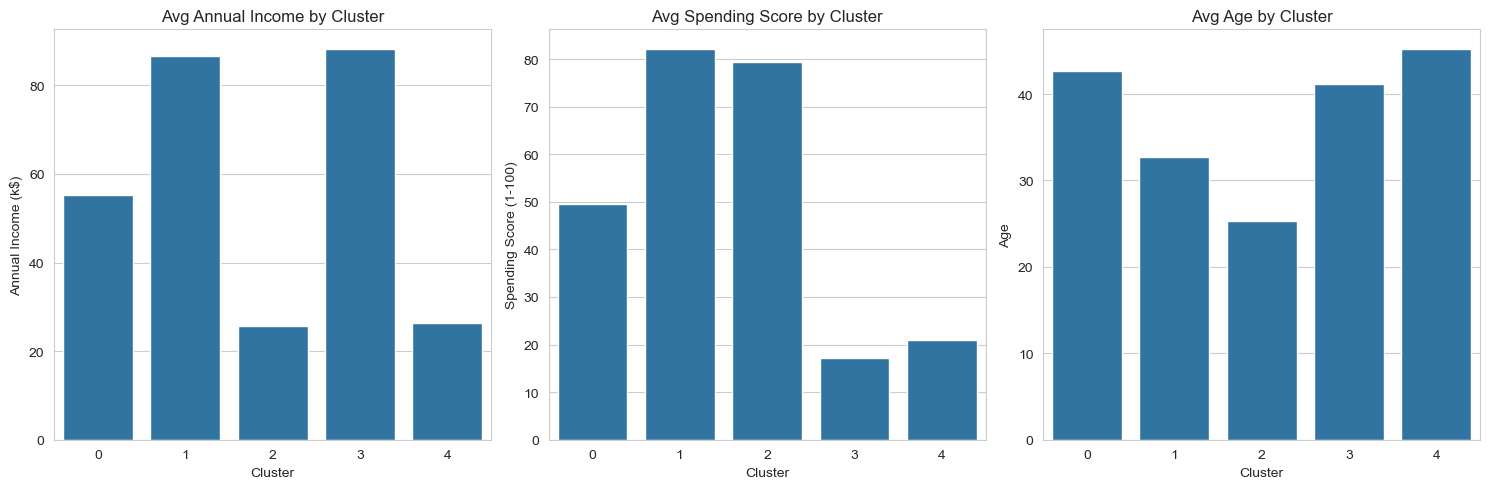

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

sns.barplot(data=cluster_summary, x='Cluster', y='Annual Income (k$)', ax=axes[0])
axes[0].set_title('Avg Annual Income by Cluster')

sns.barplot(data=cluster_summary, x='Cluster', y='Spending Score (1-100)', ax=axes[1])
axes[1].set_title('Avg Spending Score by Cluster')

sns.barplot(data=cluster_summary, x='Cluster', y='Age', ax=axes[2])
axes[2].set_title('Avg Age by Cluster')

plt.tight_layout()
plt.show()

## **Step :10. Save Results** ##

In [15]:
df.to_csv('customer_segmented.csv', index=False)